In [1]:
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl
import colorir as cl
import numpy as np
from analyses.parse import parse_cells_multiple

In [2]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path

In [3]:
sims = parse_cells_multiple(sim_paths.values(), 30)

In [4]:
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        sim_replica=sim_ids[i][1]
    )
celldf = pl.concat(sims)
celldf = celldf.with_columns(
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
)

In [5]:
grouppers = ["gamma", "sim_replica", "wtime"]
displdf = celldf.group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    mean_displ=pl.col("displ").mean(),
    med_displ=pl.col("displ").median()
).sort(grouppers)
displdf

gamma,sim_replica,wtime,cluster_x,cluster_y,mean_displ,med_displ
i32,i32,i32,f32,f32,f32,f32
0,0,0,433.300049,433.299988,614.067871,615.056519
0,0,100000,374.361847,362.397461,530.212097,546.781738
0,0,200000,318.912354,323.1073,474.199799,478.11142
0,0,300000,287.697052,289.229279,430.144165,467.157349
0,0,400000,280.46048,275.529236,425.530945,445.333221
…,…,…,…,…,…,…
20,4,14500000,77.122459,74.833153,116.028175,122.764511
20,4,14600000,82.664749,79.359482,121.106537,124.670845
20,4,14700000,89.211922,73.46209,122.026901,123.379669


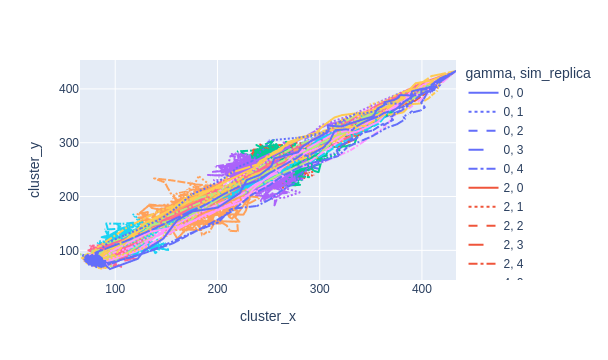

In [6]:
# Cluster trajectories
px.line(
    displdf,
    x="cluster_x",
    y="cluster_y",
    color="gamma",
    line_dash="sim_replica"
)

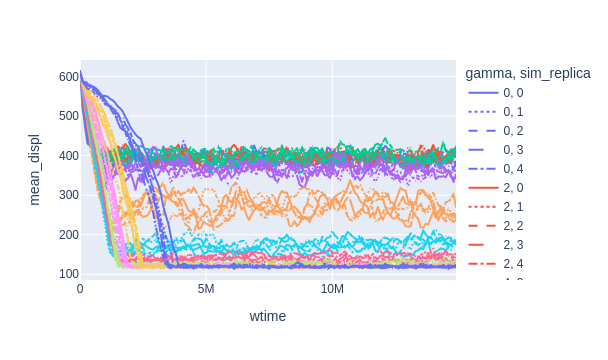

In [7]:
px.line(
    displdf,
    x="wtime",
    y="mean_displ",
    color="gamma",
    line_dash="sim_replica"
)

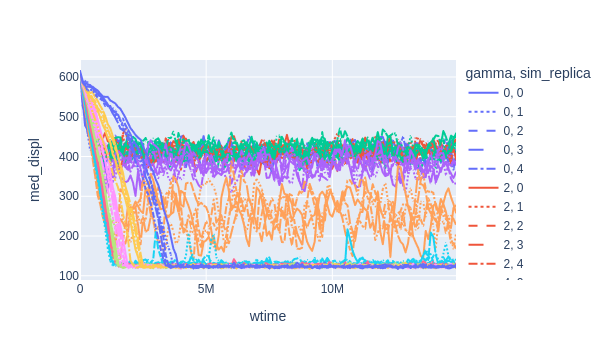

In [8]:
px.line(
    displdf,
    x="wtime",
    y="med_displ",
    color="gamma",
    line_dash="sim_replica"
)

In [9]:
repldf = displdf.group_by(["gamma", "wtime"]).agg(
    med_med=pl.col("med_displ").median(),
    med_mean=pl.col("med_displ").mean(),
    med_min=pl.col("med_displ").min(),
    med_max=pl.col("med_displ").max(),
    mean_mean=pl.col("mean_displ").mean(),
    mean_med=pl.col("mean_displ").median(),
    mean_min=pl.col("mean_displ").min(),
    mean_max=pl.col("mean_displ").max(),
).sort(["gamma", "wtime"])
repldf

gamma,wtime,med_med,med_mean,med_min,med_max,mean_mean,mean_med,mean_min,mean_max
i32,i32,f32,f32,f32,f32,f32,f32,f32,f32
0,0,615.056519,615.056519,615.056519,615.056519,614.067871,614.067871,614.067871,614.067993
0,100000,536.782532,537.724731,528.370239,546.781738,528.337341,530.212097,521.556396,534.718506
0,200000,498.899963,493.850891,478.11142,500.450867,481.424316,482.607727,474.199799,488.611176
0,300000,467.157349,465.389404,458.508728,473.991516,442.056885,443.143951,430.144165,451.102112
0,400000,445.123291,439.624664,416.558777,447.097595,427.604736,428.804565,422.975983,430.508698
…,…,…,…,…,…,…,…,…,…
20,14500000,122.293686,122.003311,120.38105,123.304123,117.562767,118.326614,115.148811,119.221054
20,14600000,124.670845,122.635887,117.901688,125.459671,119.133034,120.730263,114.031639,122.338379
20,14700000,120.881912,121.953514,119.597107,126.012596,118.925034,117.912323,116.242958,122.15612


/tmp/ipykernel_2492183/1739442699.py:3: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



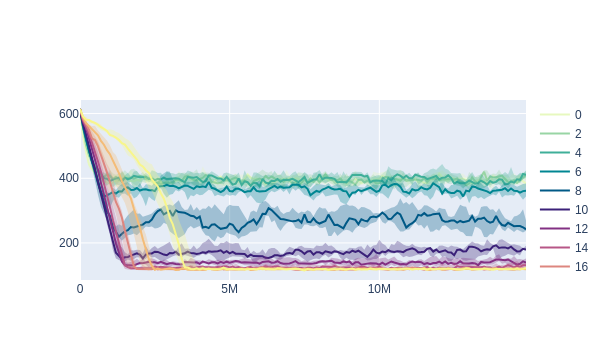

In [10]:
import random as rand

palette = cl.Grad(cl.StackPalette.load("carnival"), domain=[0, 20])
fig = go.Figure()
for gamma, group in repldf.group_by("gamma"):
    gamma = gamma[0]
    fig.add_trace(go.Scatter(
        x=group["wtime"],
        y=group["mean_med"],
        line_color=palette(gamma),
        name=gamma
    ))
    fig.add_trace(go.Scatter(
        x=pl.concat([group["wtime"], group["wtime"][::-1]]),
        y=pl.concat([group["mean_min"], group["mean_max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor=palette(gamma),
        opacity=0.3,
        showlegend=False
    ))
fig

In [11]:
concdf = displdf.filter(pl.col("wtime") > 10e6).group_by(["gamma"]).agg(
    med=pl.col("mean_displ").median(),
    min=pl.col("mean_displ").min(),
    max=pl.col("mean_displ").max(),
)
concdf

gamma,med,min,max
i32,f32,f32,f32
0,394.49118,360.31073,428.470856
2,396.237885,361.216217,427.734467
4,396.484467,354.667816,444.372894
6,364.045074,322.777588,407.120911
8,269.016846,217.816711,338.347137
…,…,…,…
12,139.383881,124.153564,165.040268
14,123.359787,114.844238,144.442886
16,119.1334,113.931862,129.960297


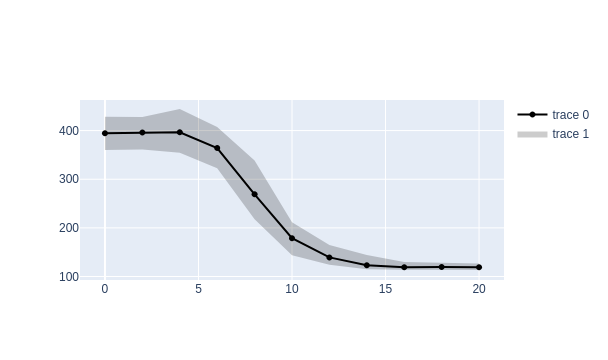

In [12]:
fig = go.Figure([
    go.Scatter(
        x=concdf["gamma"],
        y=concdf["med"],
        line_color="black"
    ),
    go.Scatter(
        x=pl.concat([concdf["gamma"], concdf["gamma"][::-1]]),
        y=pl.concat([concdf["min"], concdf["max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor="rgba(0, 0, 0, 0.2)"
    )
])
fig

In [13]:
filterdf = celldf\
    .join(displdf, on=["gamma", "sim_replica", "wtime"])\
    .group_by("gamma")\
    .agg(
        pl.col("*").filter(
            pl.col("wtime") > 0.25e6,
            pl.col("wtime") < pl.col("wtime").filter(pl.col("mean_displ") <= pl.col("mean_displ").filter(pl.col("wtime") > 1e7).mean()).min()
        )
    )\
    .explode(pl.exclude("gamma"))\
    .sort(["gamma", "sim_replica", "wtime"])
filterdf

gamma,index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,wtime,sim_replica,displ,cluster_x,cluster_y,mean_displ,med_displ
i32,u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,i32,i32,f32,f32,f32,f32,f32
0,0,0,201,200,190,180,203.990982,51.022842,203.948135,51.002487,100034,24,87,300000,0,210.275177,287.697052,289.229279,430.144165,467.157349
0,98,98,200,200,184,180,407.263855,255.159042,407.109863,255.078003,45476,190,143,300000,0,480.593353,287.697052,289.229279,430.144165,467.157349
0,97,97,201,200,184,180,122.68219,339.025452,122.704758,338.996338,69831,39,76,300000,0,360.540131,287.697052,289.229279,430.144165,467.157349
0,96,96,200,200,184,180,273.228699,218.825851,273.188721,218.803009,71584,225,3,300000,0,350.055237,287.697052,289.229279,430.144165,467.157349
0,95,95,200,200,182,180,368.850098,338.690674,368.806213,338.546967,41446,71,115,300000,0,500.7612,287.697052,289.229279,430.144165,467.157349
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,5,5,200,200,182,180,98.349213,145.60463,98.29155,145.584015,106455,34,184,3400000,4,175.707932,91.643089,71.863228,123.529892,125.507339
20,0,0,200,200,188,180,6.897346,88.534157,6.89444,88.484802,123841,40,78,3400000,4,88.802422,91.643089,71.863228,123.529892,125.507339
20,64,64,201,200,186,180,132.951797,101.024323,132.924408,101.007217,108740,24,245,3400000,4,166.979324,91.643089,71.863228,123.529892,125.507339


In [14]:
def circmean(expr):
    return pl.arctan2(expr.sin().sum(), expr.cos().sum())

def vel(colx, coly):
    xsq = pl.col(colx).diff() ** 2
    ysq = pl.col(coly).diff() ** 2
    return (xsq + ysq).sqrt()
    
cellveldf = filterdf\
    .sort("wtime")\
    .group_by(["gamma", "sim_replica", "index"])\
    .agg(
        vel=vel("center_x", "center_y").mean(),
        arc=circmean(pl.arctan2(
            pl.col("center_y").diff(), 
            pl.col("center_x").diff()
        ))
)
cellveldf

gamma,sim_replica,index,vel,arc
i32,i32,u32,f32,f32
12,1,14,36.004948,-2.404601
14,1,25,41.826389,-2.305818
18,2,88,34.401703,-2.469507
16,3,57,35.804234,-2.563195
12,2,66,53.568829,-2.24353
…,…,…,…,…
18,3,15,29.853361,-2.315489
12,1,4,55.850231,-2.156947
4,0,8,106.93177,-2.677786


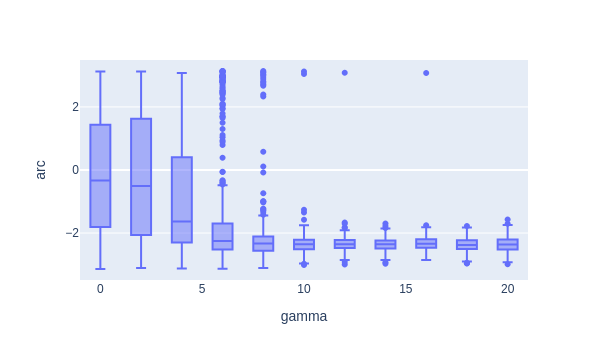

In [15]:
px.box(cellveldf, x="gamma", y="arc").update_layout(width=600)

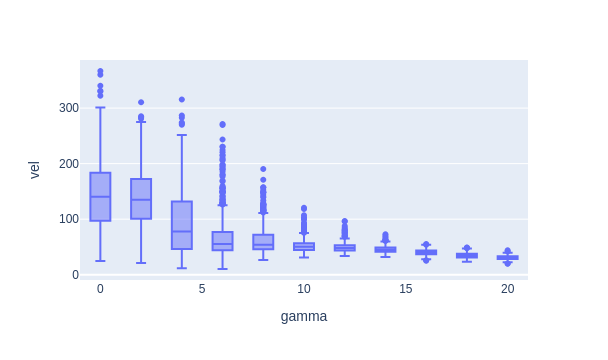

In [16]:
px.box(cellveldf, x="gamma", y="vel").update_layout(width=600)

In [128]:
def vec_alig(colx, coly):
    dot_pr = (
        pl.col(colx).diff() * -pl.col(colx)
        + pl.col(coly).diff() * -pl.col(coly)
    )
    seg_mag = (
        pl.col(colx).diff() ** 2 
        + pl.col(coly).diff() ** 2
    ).sqrt()
    ref_mag = (
        pl.col(colx) ** 2
        + pl.col(coly) ** 2
    ).sqrt()
    return dot_pr / (seg_mag * ref_mag)

clusterveldf = filterdf\
    .group_by(["gamma", "sim_replica", "wtime"])\
    .agg(
        pl.col("mean_displ").first(),
        pl.col("cluster_x").first(),
        pl.col("cluster_y").first()
    )\
    .sort(["gamma", "sim_replica", "wtime"])\
    .group_by(["gamma", "sim_replica"], maintain_order=True)\
    .agg(
        vel=vel("cluster_x", "cluster_y").mean(),
        arc=circmean(pl.arctan2(
            pl.col("cluster_y").diff(), 
            pl.col("cluster_x").diff()
        )),
        alig=vec_alig("cluster_x", "cluster_y").mean()
    )
clusterveldf

gamma,sim_replica,vel,arc,alig
i32,i32,f32,f32,f32
0,0,13.64799,-1.74762,0.766851
0,1,23.584549,-1.539903,0.661136
0,2,20.453518,-2.914099,0.797177
0,3,24.17725,-2.288673,0.960729
0,4,18.528057,2.234291,-0.01341
…,…,…,…,…
20,0,11.964211,-2.352542,0.807075
20,1,13.426,-2.4536,0.921635
20,2,15.032339,-2.238546,0.822069


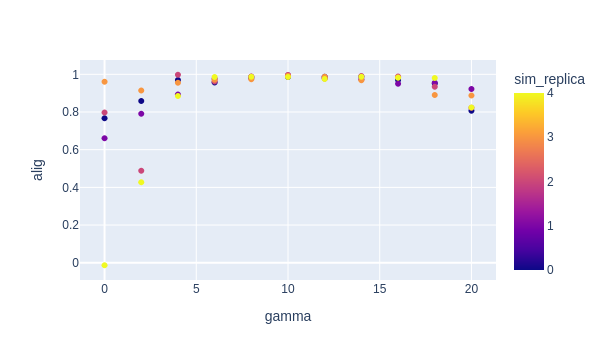

In [129]:
# Gamma = 20 makes the cluster stutter, leading to lower alignment
px.scatter(clusterveldf, x="gamma", y="alig", color="sim_replica").update_layout(width=600)

In [130]:
# Two timesteps analysed at a time
dtdf = filterdf\
    .group_by(["gamma", "sim_replica", "wtime"])\
    .agg(
        pl.col("mean_displ").first(),
        pl.col("cluster_x").first(),
        pl.col("cluster_y").first()
    )\
    .filter(pl.col("gamma") % 10 == 0)\
    .sort(["gamma", "sim_replica", "wtime"])\
    .with_row_index()\
    .group_by(["gamma", "sim_replica", pl.col("index") // 2], maintain_order=True)\
    .agg(
        pl.len(),
        vel=vel("cluster_x", "cluster_y").mean(),
        alig=vec_alig("cluster_x", "cluster_y").mean()
    )
dtdf


gamma,sim_replica,index,len,vel,alig
i32,i32,u32,u32,f32,f32
0,0,0,2,15.493842,0.95285
0,0,1,1,null,null
0,1,1,1,null,null
0,1,2,2,17.48876,0.605094
0,2,3,2,17.801104,0.949299
…,…,…,…,…,…
20,4,103,2,17.230251,0.993542
20,4,104,2,27.186249,0.891581
20,4,105,2,26.352085,0.99637


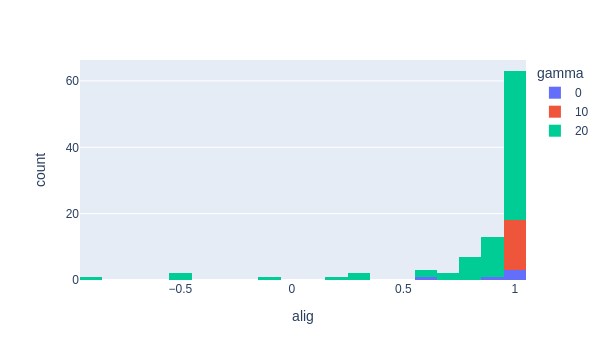

In [131]:
# Gamma 20 stutters
px.histogram(dtdf, x="alig", color="gamma")

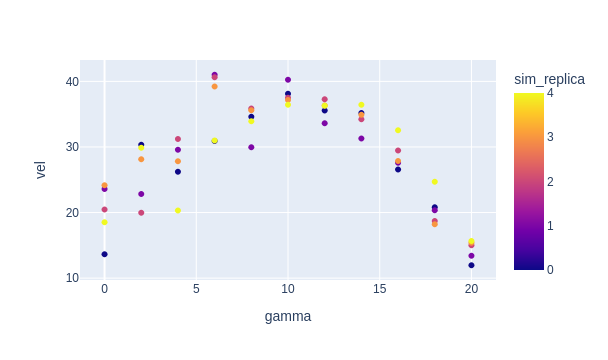

In [132]:
px.scatter(clusterveldf, x="gamma", y="vel", color="sim_replica").update_layout(width=600)

In [133]:
veldf = cellveldf.join(
    clusterveldf, 
    ["gamma", "sim_replica"],
    suffix="_cluster"
).group_by("gamma").agg(
    mean_vel=pl.col("vel").mean(),
    mean_vel_cluster=pl.col("vel_cluster").mean()
)
veldf

gamma,mean_vel,mean_vel_cluster
i32,f32,f32
18,34.414635,20.552797
10,52.184597,37.893959
4,94.447014,27.030632
8,62.483307,33.997894
16,40.306965,28.81418
…,…,…
6,69.455421,36.552238
2,138.437042,26.23683
20,30.672232,14.301256


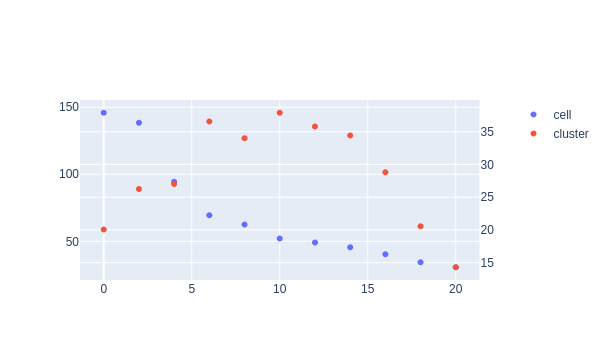

In [134]:
# Non-linear relationship between cell speed and cluster speed
# Or it is linear but strength of CIL depends on gamma? 
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_vel"],
    mode="markers",
    name="cell"
))
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_vel_cluster"],
    mode="markers",
    name="cluster"
), secondary_y=True)

In [135]:
displ_cuts = np.linspace(0, (2 * 500 ** 2) ** 0.5, 5)
time_cuts = np.arange(1e7, celldf["wtime"].max() + 5e5, 5e5)

arcdf = celldf\
    .filter(pl.col("wtime") > 1e7)\
    .with_columns(
        q_displ=pl.col("displ").cut(displ_cuts),
        q_time=pl.col("wtime").cut(time_cuts)
    )\
    .sort(["gamma", "sim_replica", "index", "displ"])\
    .group_by(["gamma", "sim_replica", "index", "q_displ"], maintain_order=True)\
    .agg(
        pl.len(),
        arc=circmean(pl.arctan2(
            pl.col("center_y").diff(), 
            pl.col("center_x").diff()
        )),
        align=vec_alig("center_x", "center_y").mean()
    )
arcdf

gamma,sim_replica,index,q_displ,len,arc,align
i32,i32,u32,cat,u32,f32,f32
0,0,0,"""(0, 176.7766952966369]""",7,1.120141,-0.336973
0,0,0,"""(176.7766952966369, 353.553390…",9,0.135995,-0.513229
0,0,0,"""(353.5533905932738, 530.330085…",21,0.714054,-0.360414
0,0,0,"""(530.3300858899106, 707.106781…",12,1.365209,-0.337653
0,0,1,"""(176.7766952966369, 353.553390…",18,1.082141,-0.414641
…,…,…,…,…,…,…
20,4,97,"""(0, 176.7766952966369]""",49,0.848131,-0.384857
20,4,98,"""(0, 176.7766952966369]""",44,1.432433,-0.310877
20,4,98,"""(176.7766952966369, 353.553390…",5,1.872448,-0.264085


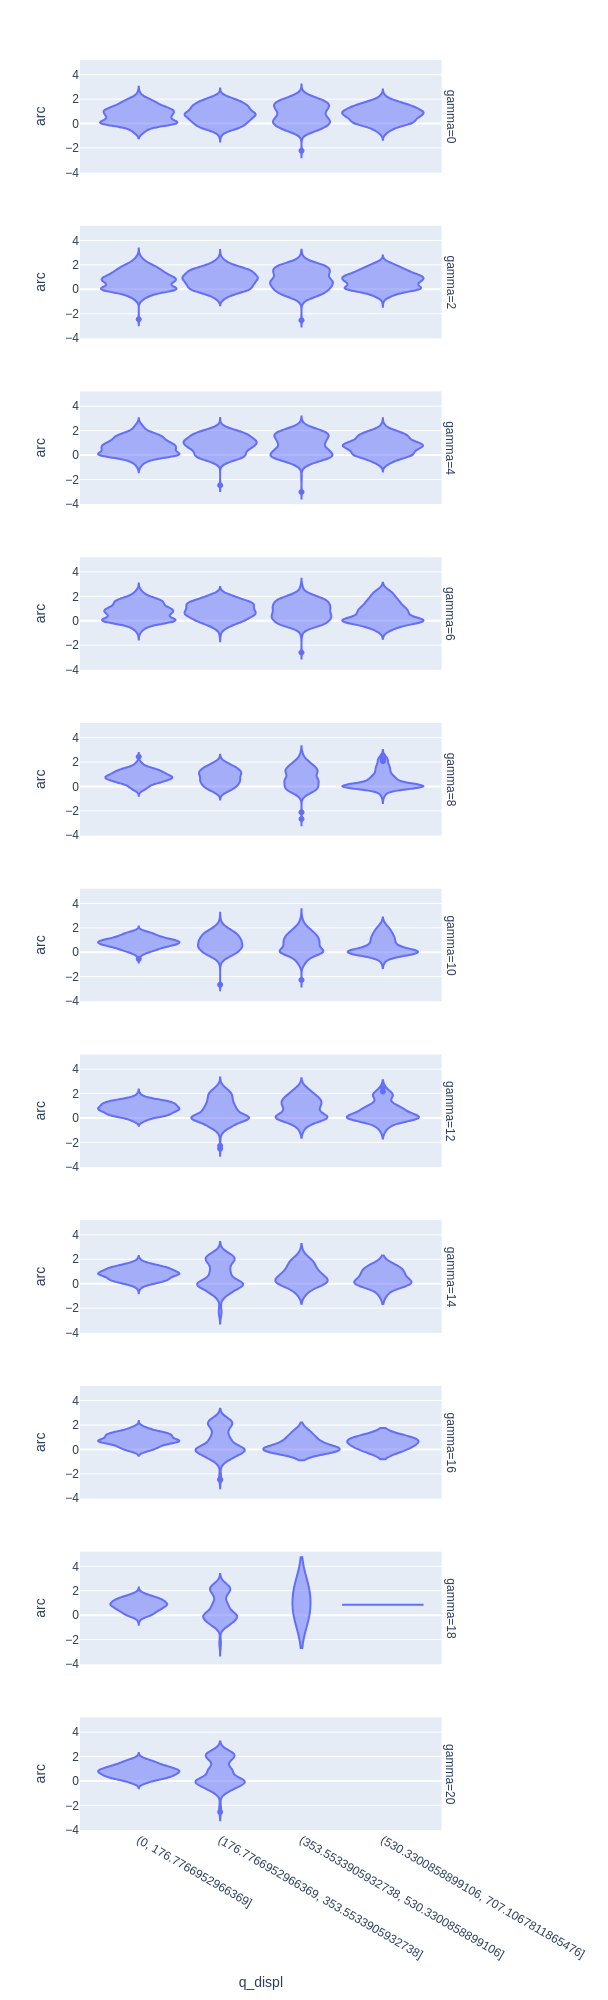

In [136]:
px.violin(
    arcdf,
    x="q_displ",
    y="arc",
    facet_row="gamma",
    violinmode="overlay",
    height=2000
).update_traces(width=1)

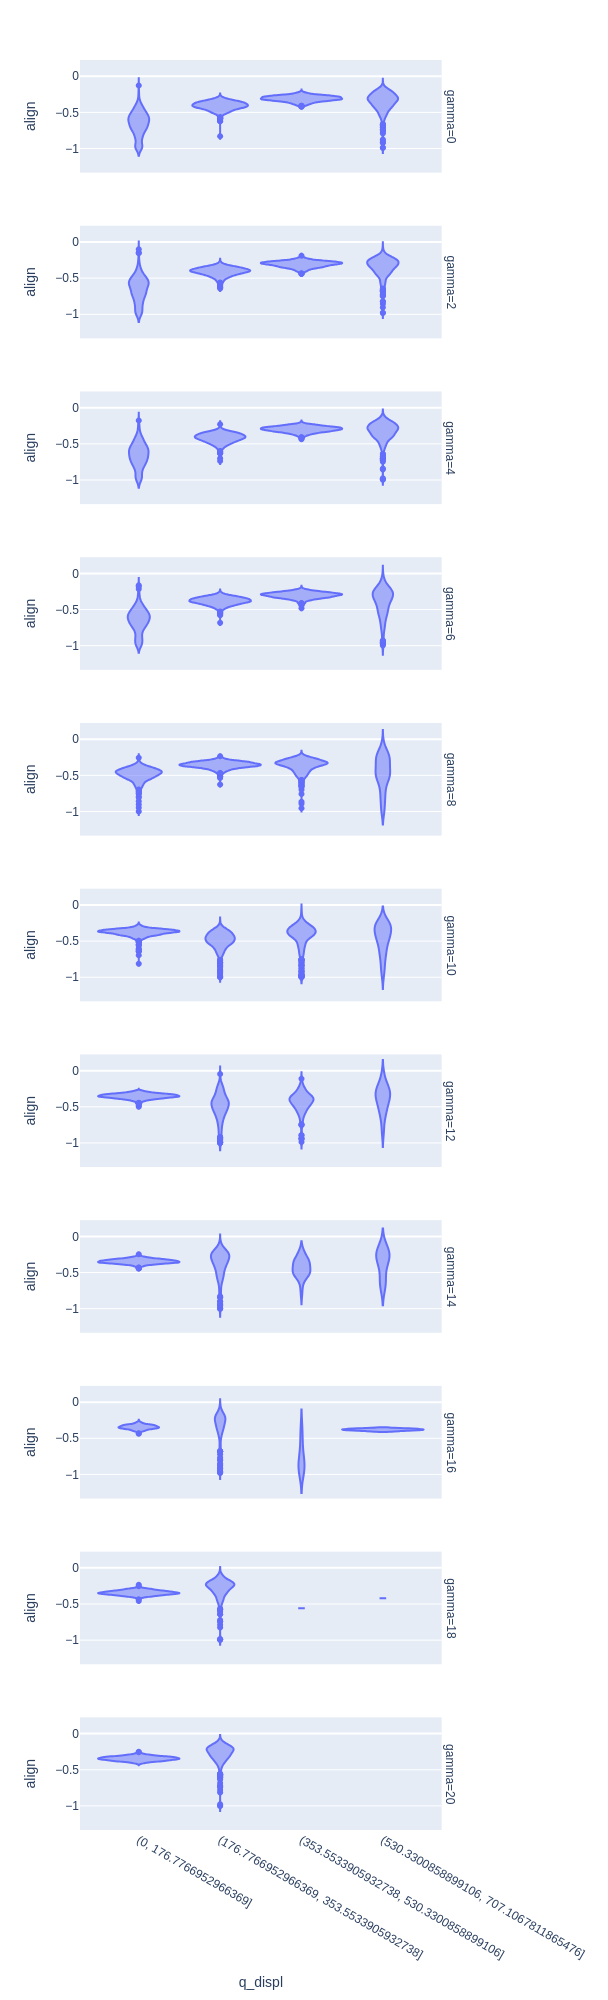

In [118]:
px.violin(
    arcdf,
    x="q_displ",
    y="align",
    facet_row="gamma",
    violinmode="overlay",
    height=2000
).update_traces(width=1)